In [2]:
# Imports
import pandas as pd 
historical_data=pd.read_csv("historical_data.csv")
fear_greed=pd.read_csv("fear_greed_index.csv")



In [3]:
print(historical_data.shape)
print(fear_greed.shape)

(211224, 16)
(2644, 4)


In [4]:
historical_data["Timestamp IST"]=pd.to_datetime(historical_data["Timestamp IST"], format="%d-%m-%Y %H:%M")
historical_data["date"]=historical_data["Timestamp IST"].dt.date
historical_data["date"]=pd.to_datetime(historical_data["date"])
fear_greed["date"]=pd.to_datetime(fear_greed["date"])
merged_df=pd.merge(historical_data,fear_greed,on="date")
missing_data=historical_data[~historical_data["date"].isin(fear_greed["date"])]
print(missing_data["date"].unique())

<DatetimeArray>
['2024-10-26 00:00:00']
Length: 1, dtype: datetime64[s]


In [5]:
print(merged_df["classification"].value_counts())

classification
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
Name: count, dtype: int64


In [6]:
pnl_by_sentiment=merged_df.groupby("classification")["Closed PnL"].agg(["mean","median","sum"])
print(pnl_by_sentiment.sort_values("mean",ascending=False))

                     mean  median           sum
classification                                 
Extreme Greed   67.892861     0.0  2.715171e+06
Fear            54.290400     0.0  3.357155e+06
Greed           42.743559     0.0  2.150129e+06
Extreme Fear    34.537862     0.0  7.391102e+05
Neutral         34.307718     0.0  1.292921e+06


In [7]:
closed_trades = merged_df[merged_df['Closed PnL'] != 0]
print(f"Total trades: {len(merged_df)}")
print(f"Closed trades with PnL: {len(closed_trades)}")

Total trades: 211218
Closed trades with PnL: 104402


In [8]:
closed_trades["is_win"]=closed_trades["Closed PnL"]>0
win_rate=closed_trades.groupby("classification")["is_win"].mean()
print(win_rate.sort_values(ascending=False))

pnl=closed_trades.groupby('classification')["Closed PnL"].agg(['mean','median'])
print(pnl.sort_values("mean",ascending=False))

trade_size=closed_trades.groupby('classification')['Size USD'].mean()
print(trade_size.sort_values(ascending=False))

classification
Extreme Greed    0.891670
Fear             0.872886
Neutral          0.823889
Greed            0.768907
Extreme Fear     0.762156
Name: is_win, dtype: float64
                      mean    median
classification                      
Extreme Greed   130.205309  8.530740
Fear            112.625988  6.350483
Greed            85.403927  4.927600
Neutral          71.199993  4.583458
Extreme Fear     71.027316  6.388050
classification
Fear             8041.140445
Neutral          5556.444833
Extreme Fear     5467.570419
Greed            5438.671764
Extreme Greed    2779.563632
Name: Size USD, dtype: float64


In [9]:
closed_trades["pnl_efficiency"]=closed_trades["Closed PnL"]/closed_trades["Size USD"]
efficiency=closed_trades.groupby("classification")["pnl_efficiency"].agg(['mean','median'])
print(efficiency.sort_values('mean',ascending=False))

                    mean    median
classification                    
Extreme Greed   0.076741  0.026713
Greed           0.039253  0.010597
Fear            0.031967  0.008178
Neutral         0.020620  0.008720
Extreme Fear    0.008887  0.009929


In [10]:
account_stats=closed_trades.groupby("Account").agg(
    win_rate=('Closed PnL', lambda x:(x>0).mean()),
    total_trades=('Closed PnL','count'),
    mean_pnl=('Closed PnL','mean'),
    total_pnl=('Closed PnL','sum'),
    mean_efficiency=('pnl_efficiency','mean')
).reset_index()
account_stats=account_stats[account_stats["total_trades"]>=20]
print(f"account with 20+ trades are:{len(account_stats)}")
print(account_stats.describe())

account with 20+ trades are:32
        win_rate  total_trades     mean_pnl     total_pnl  mean_efficiency
count  32.000000     32.000000    32.000000  3.200000e+01        32.000000
mean    0.850043   3262.562500   245.816635  3.204527e+05         0.073939
std     0.117715   4425.653784   431.412540  4.946596e+05         0.194939
min     0.599024     90.000000   -71.602360 -1.676211e+05        -0.644446
25%     0.760363    591.750000    19.449444  4.689324e+04         0.010325
50%     0.842041   1749.500000    94.324105  1.176551e+05         0.034154
75%     0.953957   4495.000000   297.114248  3.884570e+05         0.092823
max     1.000000  22551.000000  2216.728808  2.143383e+06         0.554261


In [11]:
#win rate per account per sentiment
account_sentiment=closed_trades.groupby(['Account','classification']).agg(
    total_trades=('Closed PnL','count'),
    win_rate=('Closed PnL',lambda x: (x>0).mean())
).reset_index()

win_rate_pivot=account_sentiment.pivot_table(index="Account",columns='classification',values='win_rate')
print(win_rate_pivot.head(10))

classification                              Extreme Fear  Extreme Greed  \
Account                                                                   
0x083384f897ee0f19899168e3b1bec365f52a9012      1.000000       0.256098   
0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd      0.822581       1.000000   
0x271b280974205ca63b716753467d5a371de622ab      0.980392       1.000000   
0x28736f43f1e871e6aa8b1148d38d4994275d72c4      0.593525       0.844123   
0x2c229d22b100a7beb69122eed721cee9b24011dd      1.000000       0.827784   
0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891      0.155080       0.948718   
0x39cef799f8b69da1995852eea189df24eb5cae3c      0.476821       0.890625   
0x3f9a0aadc7f04a7c9d75dc1b5a6ddd6e36486cf6      1.000000       1.000000   
0x420ab45e0bd8863569a5efbb9c05d91f40624641      1.000000       1.000000   
0x430f09841d65beb3f27765503d0f850b8bce7713           NaN       1.000000   

classification                                  Fear     Greed   Neutral  
Account                 

In [12]:
win_rate_pivot_filled=win_rate_pivot.copy()
account_sentiment_var=win_rate_pivot_filled.var(axis=1).reset_index()
account_sentiment_var.columns=['Account','sentiment_variance']
account_stats=account_stats.merge(account_sentiment_var,on="Account",how='left')

In [13]:
def segment(row):
    if row["win_rate"]>0.90 and row["sentiment_variance"]<0.02:
        return 'Consistent Winner'
    
    elif row['sentiment_variance'] >= 0.05:
        return 'Sentiment Dependent'
    
    elif row['win_rate'] < 0.70:
       return 'Consistent Loser'
    
    else:
       return 'Average Performer'
    
account_stats['segment'] = account_stats.apply(segment, axis=1)

print(account_stats['segment'].value_counts())
print()
print(account_stats.groupby('segment')[['win_rate','mean_pnl','mean_efficiency','total_trades']].mean().round(3))




segment
Average Performer      11
Sentiment Dependent    10
Consistent Winner       9
Consistent Loser        2
Name: count, dtype: int64

                     win_rate  mean_pnl  mean_efficiency  total_trades
segment                                                               
Average Performer       0.815   115.170            0.045      5204.909
Consistent Loser        0.632     7.439            0.008      4163.000
Consistent Winner       0.973   443.174            0.175      2157.667
Sentiment Dependent     0.822   259.582            0.028      1940.300


In [14]:
print(account_stats.sort_values('total_pnl',ascending=False)[['Account','total_pnl','mean_pnl','win_rate','total_trades','segment']].head(10))

                                       Account     total_pnl    mean_pnl  \
27  0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23  2.143383e+06  341.357318   
0   0x083384f897ee0f19899168e3b1bec365f52a9012  1.600230e+06  923.920219   
29  0xbaaaf6571ab7d571043ff1e313a9609a10637864  9.401638e+05   94.044594   
13  0x513b8629fe877bb581bf244e326a047b249c4ff1  8.404226e+05  153.305829   
31  0xbee1707d6b44d4d52bfe19e41f8a828645437aab  8.360806e+05   37.075099   
11  0x4acb90e786d897ecffb614dc822eb231b4ffb9f4  6.777471e+05  303.514129   
15  0x72743ae2822edd658c0c50608fd7c5c501b2afbd  4.293556e+05  582.572003   
9   0x430f09841d65beb3f27765503d0f850b8bce7713  4.165419e+05  695.395446   
17  0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4  3.790954e+05   43.775451   
16  0x72c6a4624e1dffa724e6d00d64ceae698af892a0  3.605395e+05  646.128154   

    win_rate  total_trades              segment  
27  0.791050          6279    Average Performer  
0   0.792725          1732  Sentiment Dependent  
29  0.991197 

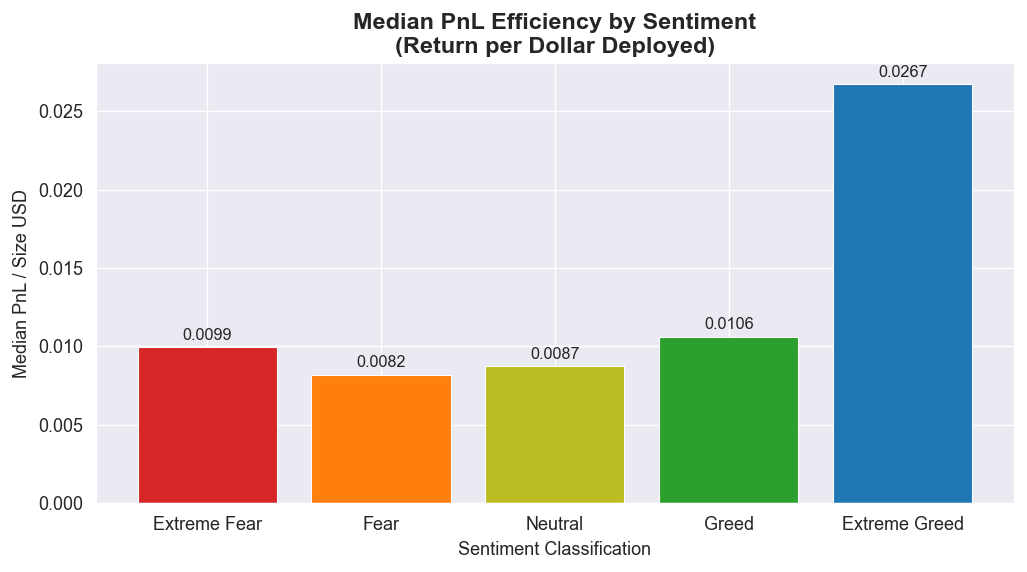

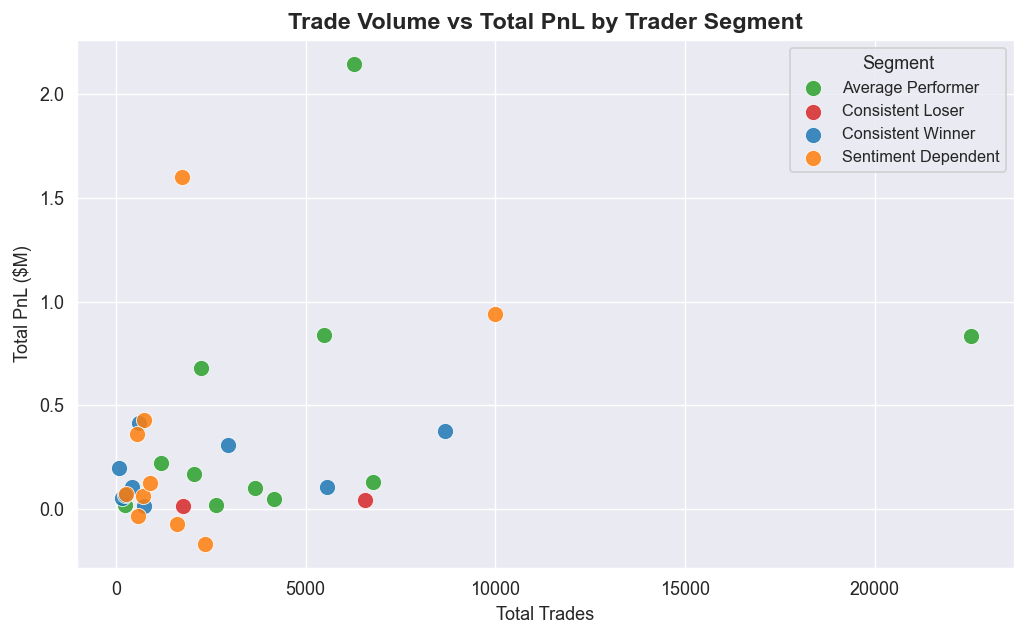

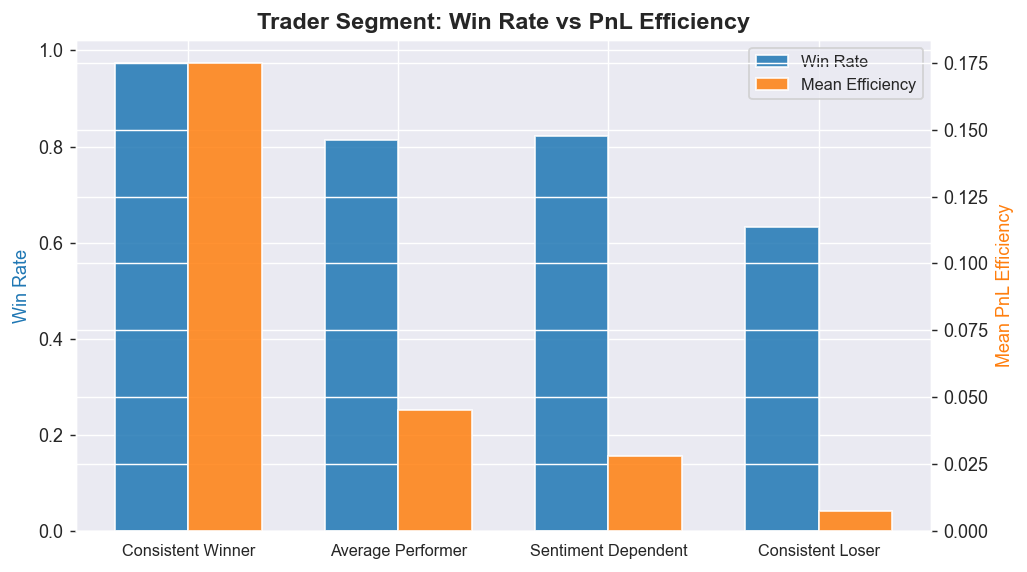

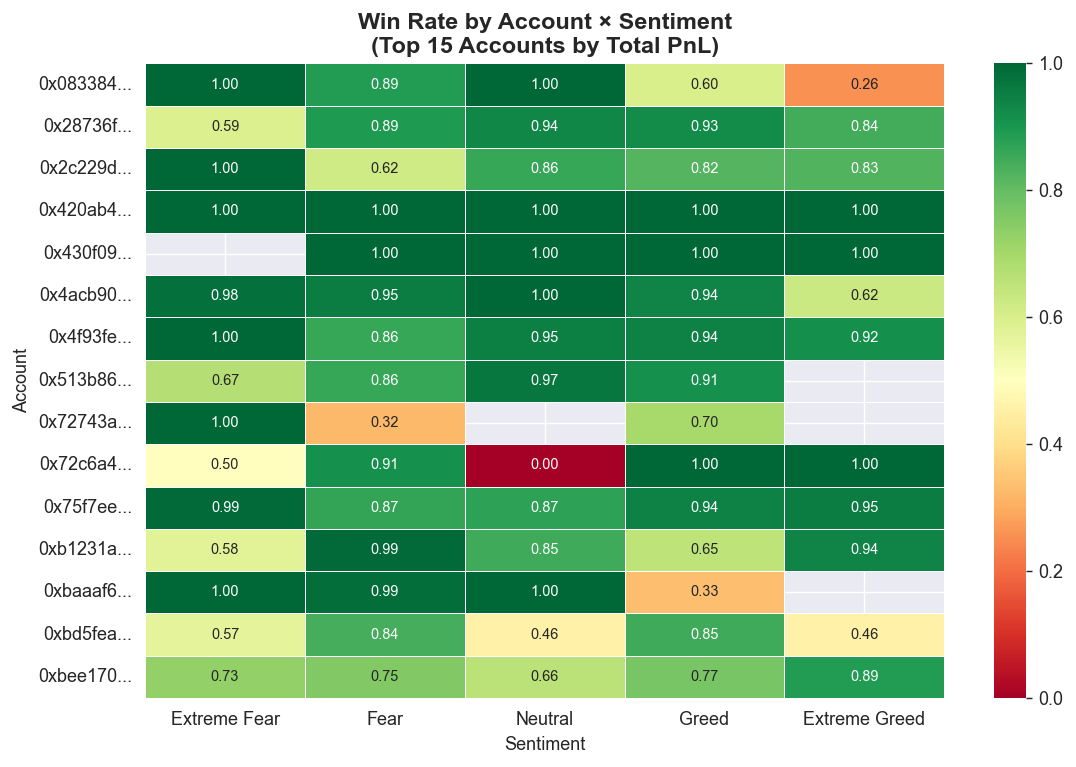

In [15]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np

plt.rcParams['figure.dpi'] = 130
plt.rcParams['font.family'] = 'sans-serif'

sns.set_style("darkgrid")

sentiment_order = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']

colors = ['#d62728', '#ff7f0e', '#bcbd22', '#2ca02c', '#1f77b4']


fig, ax = plt.subplots(figsize=(8, 4.5))

pnl_efficiency = closed_trades.groupby('classification')['pnl_efficiency'].agg(['mean', 'median'])

eff_vals = [pnl_efficiency.loc[s, 'median'] for s in sentiment_order]

bars = ax.bar(
    sentiment_order,
    eff_vals,
    color=colors,
    edgecolor='white',
    linewidth=0.6
)

ax.set_title(
    'Median PnL Efficiency by Sentiment\n(Return per Dollar Deployed)',
    fontsize=13,
    fontweight='bold'
)

ax.set_ylabel('Median PnL / Size USD')
ax.set_xlabel('Sentiment Classification')

for bar, val in zip(bars, eff_vals):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.0003,
        f'{val:.4f}',
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.tight_layout()
plt.savefig('chart1_efficiency_by_sentiment.png')
plt.show()


fig, ax = plt.subplots(figsize=(8, 5))

seg_colors = {
    'Consistent Winner': '#1f77b4',
    'Average Performer': '#2ca02c',
    'Sentiment Dependent': '#ff7f0e',
    'Consistent Loser': '#d62728'
}

for seg, grp in account_stats.groupby('segment'):
    ax.scatter(
        grp['total_trades'],
        grp['total_pnl'] / 1e6,
        label=seg,
        color=seg_colors[seg],
        s=80,
        alpha=0.85,
        edgecolors='white',
        linewidth=0.5
    )

ax.set_title(
    'Trade Volume vs Total PnL by Trader Segment',
    fontsize=13,
    fontweight='bold'
)

ax.set_xlabel('Total Trades')
ax.set_ylabel('Total PnL ($M)')

ax.legend(title='Segment', fontsize=9)

plt.tight_layout()
plt.savefig('chart2_volume_vs_pnl_segment.png')
plt.show()


seg_order = [
    'Consistent Winner',
    'Average Performer',
    'Sentiment Dependent',
    'Consistent Loser'
]

seg_summary = (
    account_stats
    .groupby('segment')[['win_rate', 'mean_efficiency']]
    .mean()
    .loc[seg_order]
)

fig, ax1 = plt.subplots(figsize=(8, 4.5))

x = np.arange(len(seg_order))
width = 0.35

bars1 = ax1.bar(
    x - width/2,
    seg_summary['win_rate'],
    width,
    label='Win Rate',
    color='#1f77b4',
    alpha=0.85,
    edgecolor='white'
)

ax2 = ax1.twinx()

bars2 = ax2.bar(
    x + width/2,
    seg_summary['mean_efficiency'],
    width,
    label='Mean Efficiency',
    color='#ff7f0e',
    alpha=0.85,
    edgecolor='white'
)

ax1.set_xticks(x)
ax1.set_xticklabels(seg_order, fontsize=9)

ax1.set_ylabel('Win Rate', color='#1f77b4')
ax2.set_ylabel('Mean PnL Efficiency', color='#ff7f0e')

ax1.set_title(
    'Trader Segment: Win Rate vs PnL Efficiency',
    fontsize=13,
    fontweight='bold'
)

lines = [bars1, bars2]
labels = ['Win Rate', 'Mean Efficiency']

ax1.legend(lines, labels, loc='upper right', fontsize=9)

plt.tight_layout()
plt.savefig('chart3_segment_winrate_efficiency.png')
plt.show()


top_accounts = account_stats.nlargest(15, 'total_pnl')['Account'].tolist()

heatmap_data = win_rate_pivot.loc[
    win_rate_pivot.index.isin(top_accounts),
    sentiment_order
]

short_labels = [a[:8] + '...' for a in heatmap_data.index]

fig, ax = plt.subplots(figsize=(9, 6))

sns.heatmap(
    heatmap_data.values,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    xticklabels=sentiment_order,
    yticklabels=short_labels,
    vmin=0,
    vmax=1,
    linewidths=0.4,
    ax=ax,
    annot_kws={'size': 8}
)

ax.set_title(
    'Win Rate by Account × Sentiment\n(Top 15 Accounts by Total PnL)',
    fontsize=13,
    fontweight='bold'
)

ax.set_xlabel('Sentiment')
ax.set_ylabel('Account')

plt.tight_layout()
plt.savefig('chart4_heatmap_account_sentiment.png')
plt.show()

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import xgboost as xgb

model_df=closed_trades.copy()
model_df['target']=(model_df["Closed PnL"]>0).astype(int)
le=LabelEncoder()
model_df['sentiment_encoded']=le.fit_transform(model_df['classification'])
model_df['side_encoded']=(model_df["Side"]=='BUY').astype(int)
account_wr=model_df.groupby('Account')["target"].transform('mean')
model_df["account_win_rate"]=account_wr
features = [
    'sentiment_encoded',
    'Size USD',
    'side_encoded',
    'account_win_rate',
    'value'
]

X = model_df[features].fillna(0)
y = model_df['target']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"Target balance — Train: {y_train.mean():.3f} | Test: {y_test.mean():.3f}")

Train: (83521, 5) | Test: (20881, 5)
Target balance — Train: 0.832 | Test: 0.832


In [17]:
scale = (y_train == 0).sum() / (y_train == 1).sum()  # ~0.20

model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale,
    eval_metric='auc',
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_metho

In [18]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("ROC-AUC:", round(roc_auc_score(y_test, y_prob), 4))
print()
print(classification_report(y_test, y_pred, target_names=['Loss', 'Win']))
print()


ROC-AUC: 0.8901

              precision    recall  f1-score   support

        Loss       0.45      0.80      0.58      3508
         Win       0.95      0.80      0.87     17373

    accuracy                           0.80     20881
   macro avg       0.70      0.80      0.72     20881
weighted avg       0.87      0.80      0.82     20881




In [19]:
importance_df = pd.DataFrame({
    'feature': features,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print(importance_df)

             feature  importance
3   account_win_rate    0.363334
4              value    0.226402
2       side_encoded    0.187019
0  sentiment_encoded    0.161012
1           Size USD    0.062233


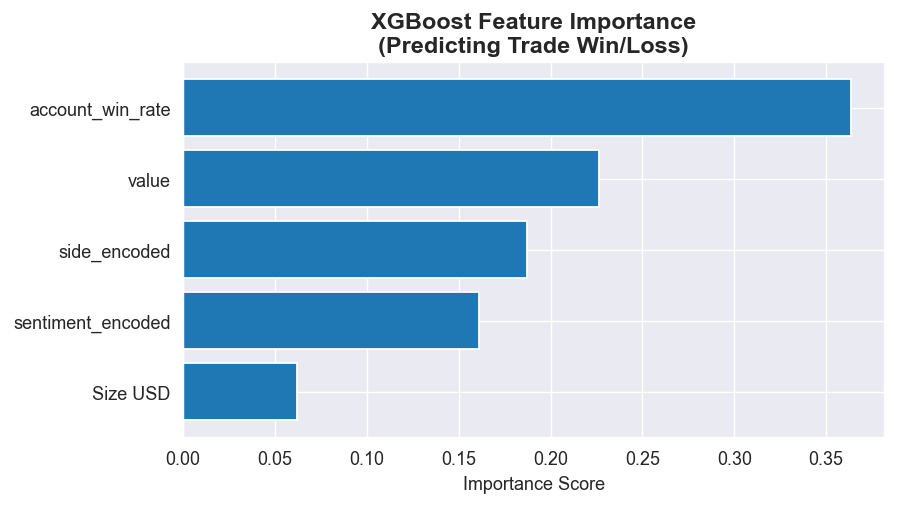

In [20]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(importance_df['feature'][::-1], importance_df['importance'][::-1],
        color='#1f77b4', edgecolor='white')
ax.set_title('XGBoost Feature Importance\n(Predicting Trade Win/Loss)', 
             fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig('chart5_feature_importance.png')
plt.show()